# Nova 50M Transactions Super App — Exploratory Data Analysis

[Kaggle link](https://www.kaggle.com/datasets/adityathakekar/nova-50m-transactions-super-app)

This notebook uses **Polars** for memory-conscious exploration of the large local Parquet interaction file.

Dataset tables:

- `data/raw/nova_interactions.parquet` — large fact table, ~50M transactions/interactions
- `data/raw/nova_users.parquet` — user dimension table
- `data/raw/nova_services.parquet` — service / merchant dimension table

Primary goals:

1. Ingest the data safely without loading the massive interaction file into memory.
2. Inspect schemas, keys, quality issues, categories, date ranges, and distributions.
3. Build first KPI tables for business analysis.
4. Identify candidate business problems for BI dashboards and ML/modeling.
5. Export useful lightweight artifacts to `data/processed/nova_outputs/`.

Recommended stack for this notebook: **Polars lazy scanning + aggregated outputs**. Avoid pandas on the massive interaction table.


## Environment notes

The large interaction table should be handled lazily with `pl.scan_parquet()`. Small dimension tables can be loaded eagerly.

If you run this locally, start Jupyter from the repository root or from `notebooks/`; the path cell handles both.


In [2]:
# Imports
from pathlib import Path
import os
import gc

import polars as pl
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

print("Polars version:", pl.__version__)

Polars version: 1.41.2


In [3]:
# Define paths
NOTEBOOK_CWD = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_CWD if (NOTEBOOK_CWD / "data").exists() else NOTEBOOK_CWD.parent

DATA_DIR = REPO_ROOT / "data" / "raw"

SERVICES_PATH = DATA_DIR / "nova_services.parquet"
USERS_PATH = DATA_DIR / "nova_users.parquet"
INTERACTIONS_PATH = DATA_DIR / "nova_interactions.parquet"

for path in [SERVICES_PATH, USERS_PATH, INTERACTIONS_PATH]:
    print(f"{path.name:<35} {path.stat().st_size / (1024**3):>8.2f} GiB")


nova_services.parquet                   0.00 GiB
nova_users.parquet                      0.00 GiB
nova_interactions.parquet               2.56 GiB


## 1. Load small dimension tables

`services` and `users` are small enough to read eagerly. The users table has 2M rows, but only 4 columns, so it is manageable.


In [4]:
# Read in & inspect the tables
services = pl.read_parquet(SERVICES_PATH)
users = pl.read_parquet(USERS_PATH)

print("services:", services.shape)
print("users:", users.shape)

display(services.head().to_pandas())
display(users.head().to_pandas())


services: (50000, 4)
users: (2000000, 4)


,Service_ID,Merchant_Name,Category,Rating
0,1,Store_1,Food Delivery,4.9
1,2,Store_2,Grocery,4.4
2,3,Store_3,Ride Hailing,4.1
3,4,Store_4,Ride Hailing,3.6
4,5,Store_5,Digital Wallet,4.9


,User_ID,Join_Date,Membership_Tier,Primary_Device
0,1,2023-10-24,Standard,Android
1,2,2023-01-25,Standard,Android
2,3,2023-05-06,Standard,iOS
3,4,2023-06-26,Standard,iOS
4,5,2023-05-18,Standard,Android


In [5]:
print("Services schema:")
print(services.schema)

print("Users schema:")
print(users.schema)

Services schema:
Schema({'Service_ID': Int64, 'Merchant_Name': String, 'Category': String, 'Rating': Float64})
Users schema:
Schema({'User_ID': Int64, 'Join_Date': Date, 'Membership_Tier': String, 'Primary_Device': String})


## 2. Scan the massive interactions table lazily

Use `collect_schema()` rather than `.schema` on the LazyFrame to avoid performance issues.


In [6]:
# Scan Parquet instead of reading the full interaction table
interactions_lf = pl.scan_parquet(INTERACTIONS_PATH)

# Use collect_schema() instead of interactions_lf.schema to avoid PerformanceWarning.
interactions_schema = interactions_lf.collect_schema()
interaction_columns = list(interactions_schema.names())

print(interactions_schema)


Schema({'Transaction_UUID': String, 'User_ID': Int64, 'Service_ID': Int64, 'Timestamp': String, 'Category': String, 'Amount_USD': Float64, 'Status': String, 'Platform_User_Agent': String, 'Referral_Source': String, 'GPS_Lat': Float64, 'GPS_Long': Float64, 'Timestamp_dt': Datetime(time_unit='us', time_zone=None), 'Date': Date, 'Month': Datetime(time_unit='us', time_zone=None), 'Hour': Int8})


In [7]:
# Preview without collecting the whole table.
interaction_head = interactions_lf.head(5).collect()
display(interaction_head.to_pandas())

,Transaction_UUID,User_ID,Service_ID,Timestamp,Category,Amount_USD,Status,Platform_User_Agent,Referral_Source,GPS_Lat,GPS_Long,Timestamp_dt,Date,Month,Hour
0,7791b178-c0f8-491a-b8dd-ed6a063b35f3,1464182,7367,2024-10-31 16:31:30,Food Delivery,5.86,Completed,Nova Web Portal (Chrome 120.0),Organic Search,-39.65088,32.27006,2024-10-31 16:31:30,2024-10-31,2024-10-01,16
1,005d19ea-3b35-461d-9adc-d92a864a0e13,1285826,7599,2024-06-13 13:54:26,Grocery,99.27,Completed,Nova App v4.2 (Android 14; Samsung S23),Friend Referral,-5.18329,-74.97179,2024-06-13 13:54:26,2024-06-13,2024-06-01,13
2,57d134b8-e772-4eeb-bd91-5ebdc58fd290,657307,14144,2024-11-11 06:45:05,Food Delivery,83.40,Completed,Nova Lite (Android Go),Email Promo,-18.61433,54.66788,2024-11-11 06:45:05,2024-11-11,2024-11-01,6
3,856e6a22-064e-4943-87d9-cd7caf578fb8,1154402,11714,2024-07-25 18:33:50,Digital Wallet,41.15,Completed,Nova Lite (Android Go),Social Ad,37.56500,-143.98500,2024-07-25 18:33:50,2024-07-25,2024-07-01,18
4,161d6e70-ce2c-4e88-9907-3246887bea7b,111060,6955,2024-11-23 05:04:55,Digital Wallet,43.20,Completed,Nova App v4.2 (iOS 17.1; iPhone 14 Pro),Push Notification,-51.56120,-28.73065,2024-11-23 05:04:55,2024-11-23,2024-11-01,5


## 3. Known schema and table roles

Expected interaction schema:

- `Transaction_UUID`: transaction identifier
- `User_ID`: foreign key to users
- `Service_ID`: foreign key to services
- `Timestamp`: transaction timestamp, initially string
- `Category`: service category on the transaction record
- `Amount_USD`: transaction value
- `Status`: transaction status
- `Platform_User_Agent`: device/app/channel signal
- `Referral_Source`: acquisition/referral source
- `GPS_Lat`, `GPS_Long`: location coordinates

Likely data model:

- `interactions` = fact table
- `users` = user dimension
- `services` = service/merchant dimension


## 4. Row counts and key checks

These operations scan data but return tiny results.


In [8]:
row_counts = {
    "services": services.height,
    "users": users.height,
    "interactions": interactions_lf.select(pl.len().alias("n_rows")).collect().item(),
}
row_counts

{'services': 50000, 'users': 2000000, 'interactions': 50000000}

In [9]:
# Dimension uniqueness checks
service_key_check = services.select(
    pl.len().alias("n_rows"),
    pl.col("Service_ID").n_unique().alias("n_unique_service_id"),
    pl.col("Merchant_Name").n_unique().alias("n_unique_merchant_name"),
)

user_key_check = users.select(
    pl.len().alias("n_rows"),
    pl.col("User_ID").n_unique().alias("n_unique_user_id"),
)

display(service_key_check.to_pandas())
display(user_key_check.to_pandas())

,n_rows,n_unique_service_id,n_unique_merchant_name
0,50000,50000,50000


,n_rows,n_unique_user_id
0,2000000,2000000


In [10]:
# Fact table key and foreign-key coverage checks.
# This scans the full interaction file.
interaction_key_check = interactions_lf.select(
    pl.len().alias("n_rows"),
    pl.col("Transaction_UUID").n_unique().alias("n_unique_transaction_uuid"),
    pl.col("User_ID").n_unique().alias("n_unique_users_in_interactions"),
    pl.col("Service_ID").n_unique().alias("n_unique_services_in_interactions"),
).collect()

display(interaction_key_check.to_pandas())

,n_rows,n_unique_transaction_uuid,n_unique_users_in_interactions,n_unique_services_in_interactions
0,50000000,50000000,2000000,50000


## 5. Missingness profiling

This scans the full interaction table once. It is useful before deeper analysis.


In [11]:
def null_profile_eager(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df.select([pl.col(c).null_count().alias(c) for c in df.columns])
        .transpose(include_header=True, header_name="column", column_names=["null_count"])
        .with_columns((pl.col("null_count") / df.height).alias("null_rate"))
        .sort("null_rate", descending=True)
    )

services_nulls = null_profile_eager(services)
users_nulls = null_profile_eager(users)

display(services_nulls.to_pandas())
display(users_nulls.to_pandas())

,column,null_count,null_rate
0,Service_ID,0,0.0
1,Merchant_Name,0,0.0
2,Category,0,0.0
3,Rating,0,0.0


,column,null_count,null_rate
0,User_ID,0,0.0
1,Join_Date,0,0.0
2,Membership_Tier,0,0.0
3,Primary_Device,0,0.0


In [12]:
interaction_nulls = (
    interactions_lf
    .select([pl.col(c).null_count().alias(c) for c in interaction_columns])
    .collect()
    .transpose(include_header=True, header_name="column", column_names=["null_count"])
    .with_columns((pl.col("null_count") / row_counts["interactions"]).alias("null_rate"))
    .sort("null_rate", descending=True)
)

display(interaction_nulls.to_pandas())

,column,null_count,null_rate
0,Transaction_UUID,0,0.0
1,User_ID,0,0.0
2,Service_ID,0,0.0
3,Timestamp,0,0.0
4,Category,0,0.0
5,Amount_USD,0,0.0
6,Status,0,0.0
7,Platform_User_Agent,0,0.0
8,Referral_Source,0,0.0
9,GPS_Lat,0,0.0


## 6. Parse timestamps and create reusable typed lazy frame

The raw `Timestamp` column is string. We create `Timestamp_dt`, `Date`, `Month`, and `Hour` for time-series analysis.


In [13]:
# Inspect timestamp examples first.
timestamp_examples = interactions_lf.select("Timestamp").head(10).collect()
display(timestamp_examples.to_pandas())

,Timestamp
0,2024-10-31 16:31:30
1,2024-06-13 13:54:26
2,2024-11-11 06:45:05
3,2024-07-25 18:33:50
4,2024-11-23 05:04:55
5,2024-01-17 15:33:51
6,2024-01-14 20:26:29
7,2024-01-11 04:17:10
8,2024-08-08 19:52:51
9,2024-11-20 00:32:14


In [14]:
temporal_columns = {"Timestamp_dt", "Date", "Month", "Hour"}

if temporal_columns.issubset(set(interaction_columns)):
    interactions_typed_lf = interactions_lf
else:
    interactions_typed_lf = interactions_lf.with_columns(
        pl.col("Timestamp").str.to_datetime(strict=False).alias("Timestamp_dt")
    ).with_columns(
        pl.col("Timestamp_dt").dt.date().alias("Date"),
        pl.col("Timestamp_dt").dt.truncate("1mo").alias("Month"),
        pl.col("Timestamp_dt").dt.hour().alias("Hour"),
    )

interactions_typed_lf.select(
    pl.col("Timestamp_dt").min().alias("min_timestamp"),
    pl.col("Timestamp_dt").max().alias("max_timestamp"),
    pl.col("Date").n_unique().alias("n_dates"),
).collect()


min_timestamp,max_timestamp,n_dates
datetime[μs],datetime[μs],u32
2024-01-01 00:00:02,2024-12-30 23:59:59,365


## 7. Categorical profiling

Start with the main business dimensions: category, status, user agent, referral source.


In [15]:
def lazy_value_counts(lf: pl.LazyFrame, col: str, limit: int = 30) -> pl.DataFrame:
    return (
        lf.group_by(col)
        .agg(pl.len().alias("n"))
        .with_columns((pl.col("n") / pl.col("n").sum()).alias("share"))
        .sort("n", descending=True)
        .limit(limit)
        .collect()
    )

for col in ["Category", "Status", "Platform_User_Agent", "Referral_Source"]:
    print(f"Top values for {col}")
    out = lazy_value_counts(interactions_typed_lf, col, limit=20)
    display(out.to_pandas())

Top values for Category


,Category,n,share
0,Food Delivery,20003439,0.400069
1,Ride Hailing,10001744,0.200035
2,E-Commerce,9997890,0.199958
3,Grocery,4998923,0.099978
4,Digital Wallet,4998004,0.099960


Top values for Status


,Status,n,share
0,Completed,45000712,0.900014
1,Refunded,2500952,0.050019
2,Failed,2498336,0.049967


Top values for Platform_User_Agent


,Platform_User_Agent,n,share
0,Nova Lite (Android Go),12505490,0.250110
1,Nova App v4.2 (iOS 17.1; iPhone 14 Pro),12501716,0.250034
2,Nova App v4.2 (Android 14; Samsung S23),12497978,0.249960
3,Nova Web Portal (Chrome 120.0),12494816,0.249896


Top values for Referral_Source


,Referral_Source,n,share
0,Push Notification,10003037,0.200061
1,Email Promo,10002456,0.200049
2,Organic Search,10001835,0.200037
3,Friend Referral,9998636,0.199973
4,Social Ad,9994036,0.199881


In [16]:
# Dimension table category profile
service_category_profile = (
    services
    .group_by("Category")
    .agg(
        pl.len().alias("n_services"),
        pl.col("Rating").mean().alias("avg_rating"),
        pl.col("Rating").median().alias("median_rating"),
        pl.col("Rating").min().alias("min_rating"),
        pl.col("Rating").max().alias("max_rating"),
    )
    .sort("n_services", descending=True)
)

display(service_category_profile.to_pandas())

,Category,n_services,avg_rating,median_rating,min_rating,max_rating
0,Grocery,10174,4.003922,4.0,3.0,5.0
1,Ride Hailing,10068,4.001778,4.0,3.0,5.0
2,E-Commerce,10020,4.003234,4.0,3.0,5.0
3,Food Delivery,9899,3.998656,4.0,3.0,5.0
4,Digital Wallet,9839,4.000579,4.0,3.0,5.0


In [17]:
user_profile = (
    users
    .group_by(["Membership_Tier", "Primary_Device"])
    .agg(pl.len().alias("n_users"))
    .with_columns((pl.col("n_users") / users.height).alias("user_share"))
    .sort("n_users", descending=True)
)

display(user_profile.to_pandas())

,Membership_Tier,Primary_Device,n_users,user_share
0,Standard,iOS,799644,0.399822
1,Standard,Android,799377,0.399689
2,Gold,Android,150752,0.075376
3,Gold,iOS,150449,0.075224
4,Platinum,Android,49966,0.024983
5,Platinum,iOS,49812,0.024906


## 8. Numeric profiling for `Amount_USD`

Look for outliers, zero/negative values, and the general transaction value distribution.


In [18]:
amount_profile = interactions_typed_lf.select(
    pl.col("Amount_USD").count().alias("n_non_null"),
    pl.col("Amount_USD").null_count().alias("n_null"),
    pl.col("Amount_USD").min().alias("min"),
    pl.col("Amount_USD").quantile(0.01).alias("p01"),
    pl.col("Amount_USD").quantile(0.05).alias("p05"),
    pl.col("Amount_USD").quantile(0.25).alias("p25"),
    pl.col("Amount_USD").median().alias("p50"),
    pl.col("Amount_USD").quantile(0.75).alias("p75"),
    pl.col("Amount_USD").quantile(0.95).alias("p95"),
    pl.col("Amount_USD").quantile(0.99).alias("p99"),
    pl.col("Amount_USD").max().alias("max"),
    pl.col("Amount_USD").mean().alias("mean"),
    pl.col("Amount_USD").std().alias("std"),
    (pl.col("Amount_USD") <= 0).sum().alias("n_non_positive"),
).collect()

display(amount_profile.to_pandas())

,n_non_null,n_null,min,p01,p05,p25,p50,p75,p95,p99,max,mean,std,n_non_positive
0,50000000,0,5.0,6.45,12.25,41.25,77.5,113.74,142.75,148.55,150.0,77.49901,41.858002,0


## 9. Data quality checks

These checks help decide what should become dbt tests later.


In [19]:
quality_checks = interactions_typed_lf.select(
    pl.len().alias("n_rows"),
    pl.col("Transaction_UUID").is_null().sum().alias("null_transaction_uuid"),
    pl.col("User_ID").is_null().sum().alias("null_user_id"),
    pl.col("Service_ID").is_null().sum().alias("null_service_id"),
    pl.col("Timestamp_dt").is_null().sum().alias("unparseable_timestamp"),
    (pl.col("Amount_USD") <= 0).sum().alias("non_positive_amount"),
    ((pl.col("GPS_Lat") < -90) | (pl.col("GPS_Lat") > 90)).sum().alias("invalid_latitude"),
    ((pl.col("GPS_Long") < -180) | (pl.col("GPS_Long") > 180)).sum().alias("invalid_longitude"),
).collect()

display(quality_checks.to_pandas())

,n_rows,null_transaction_uuid,null_user_id,null_service_id,unparseable_timestamp,non_positive_amount,invalid_latitude,invalid_longitude
0,50000000,0,0,0,0,0,0,0


In [20]:
# Check whether interaction category matches service dimension category after joining on Service_ID.
# This is a useful consistency test.
services_for_join = services.select(
    "Service_ID",
    pl.col("Category").alias("Service_Category"),
    "Merchant_Name",
    "Rating",
).lazy()

category_consistency = (
    interactions_typed_lf
    .select("Service_ID", "Category")
    .join(services_for_join, on="Service_ID", how="left")
    .select(
        pl.len().alias("n_rows"),
        pl.col("Service_Category").is_null().sum().alias("missing_service_dimension_match"),
        (pl.col("Category") != pl.col("Service_Category")).sum().alias("category_mismatch_count"),
    )
    .collect()
)

display(category_consistency.to_pandas())

,n_rows,missing_service_dimension_match,category_mismatch_count
0,50000000,0,40018166


## 10. Create a manageable row-level sample

Use this for detailed inspection, scatter plots, and quick modeling prototypes. Do not use it for final KPI counts.


In [21]:
SAMPLE_MOD = 1000  # keeps roughly 1/1000 rows, about 50k from 50M

interaction_sample = (
    interactions_typed_lf
    .with_columns(
        (
            pl.col("Transaction_UUID")
            .hash(seed=42)
            .mod(SAMPLE_MOD)
            .alias("sample_bucket")
        )
    )
    .filter(pl.col("sample_bucket") == 0)
    .drop("sample_bucket")
    .collect()
)

print(interaction_sample.shape)
display(interaction_sample.head().to_pandas())

(50209, 15)


,Transaction_UUID,User_ID,Service_ID,Timestamp,Category,Amount_USD,Status,Platform_User_Agent,Referral_Source,GPS_Lat,GPS_Long,Timestamp_dt,Date,Month,Hour
0,2afe27b7-1644-4921-bddf-88fefce5fbac,5343,45570,2024-08-07 12:47:51,Ride Hailing,31.63,Completed,Nova App v4.2 (iOS 17.1; iPhone 14 Pro),Email Promo,81.81093,-30.59091,2024-08-07 12:47:51,2024-08-07,2024-08-01,12
1,a9534b55-cbc3-4780-9a64-de7f7614be2f,1891939,49449,2024-06-12 01:23:58,E-Commerce,86.18,Completed,Nova Lite (Android Go),Social Ad,89.61950,-154.95546,2024-06-12 01:23:58,2024-06-12,2024-06-01,1
2,155eada7-da01-4252-b6ac-06a2daff6276,1513821,37194,2024-05-01 14:16:38,Food Delivery,66.84,Completed,Nova Web Portal (Chrome 120.0),Friend Referral,21.69087,-140.03897,2024-05-01 14:16:38,2024-05-01,2024-05-01,14
3,bdd956f2-446d-4d2a-9379-3569b55dd4f1,1761921,39564,2024-02-05 02:45:24,Food Delivery,108.16,Completed,Nova Web Portal (Chrome 120.0),Friend Referral,-31.39574,-14.52147,2024-02-05 02:45:24,2024-02-05,2024-02-01,2
4,c9b953dc-9724-4a72-9882-5e1c9c5a5817,277411,14778,2024-12-14 23:32:51,Food Delivery,13.51,Completed,Nova App v4.2 (iOS 17.1; iPhone 14 Pro),Friend Referral,-67.05842,-2.79121,2024-12-14 23:32:51,2024-12-14,2024-12-01,23


In [22]:
WORK_DIR = REPO_ROOT / "data" / "processed" / "nova_outputs"
WORK_DIR.mkdir(parents=True, exist_ok=True)

interaction_sample.write_parquet(WORK_DIR / "interactions_sample_0_1pct.parquet")
services.write_parquet(WORK_DIR / "services.parquet")
users.write_parquet(WORK_DIR / "users.parquet")

print("Saved sample and dimension parquet files to:", WORK_DIR)


Saved sample and dimension parquet files to: /Users/doruk/dev/nova-analytics/data/processed/nova_outputs


## 11. Build first KPI tables

These are the kinds of outputs that can later become dbt marts and BI dashboard tables.


### 11.1 Monthly executive KPIs

In [23]:
monthly_kpis = (
    interactions_typed_lf
    .group_by("Month")
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Service_ID").n_unique().alias("active_services"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        pl.col("Amount_USD").mean().alias("avg_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
    )
    .with_columns(
        (pl.col("n_transactions") / pl.col("active_users")).alias("transactions_per_active_user"),
        (pl.col("total_amount_usd") / pl.col("active_users")).alias("amount_per_active_user"),
    )
    .sort("Month")
    .collect()
)

display(monthly_kpis.to_pandas())
monthly_kpis.write_parquet(WORK_DIR / "monthly_kpis.parquet")

,Month,n_transactions,active_users,active_services,total_amount_usd,avg_amount_usd,completion_rate,transactions_per_active_user,amount_per_active_user
0,2024-01-01,4250104,1761812,50000,3.293702e+08,77.496970,0.899964,2.412348,186.949675
1,2024-02-01,3969517,1725261,50000,3.076242e+08,77.496640,0.900115,2.300821,178.305909
2,2024-03-01,4249167,1761213,50000,3.292384e+08,77.483036,0.899858,2.412637,186.938410
3,2024-04-01,4108065,1743657,50000,3.184576e+08,77.520107,0.899917,2.356005,182.637776
4,2024-05-01,4243308,1760549,50000,3.288600e+08,77.500847,0.900332,2.410219,186.793987
5,2024-06-01,4109448,1743595,50000,3.184341e+08,77.488279,0.899867,2.356882,182.630744
6,2024-07-01,4248893,1760868,50000,3.293618e+08,77.517078,0.900015,2.412954,187.045123
7,2024-08-01,4247766,1760672,50000,3.290824e+08,77.471866,0.899966,2.412582,186.907248
8,2024-09-01,4108238,1743417,50000,3.184347e+08,77.511265,0.899990,2.356429,182.649776
9,2024-10-01,4245011,1760229,50000,3.290288e+08,77.509528,0.900072,2.411624,186.923860


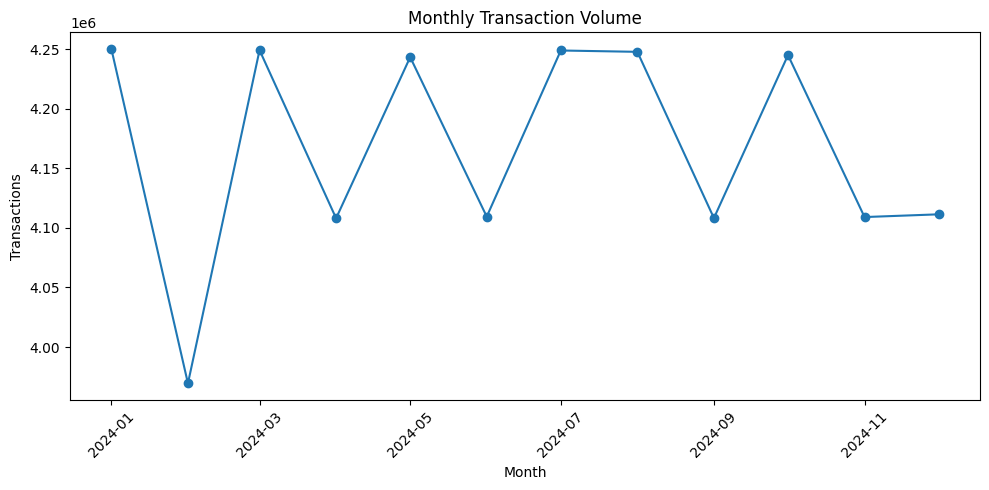

In [24]:
monthly_pd = monthly_kpis.to_pandas()

plt.figure(figsize=(10, 5))
plt.plot(monthly_pd["Month"], monthly_pd["n_transactions"], marker="o")
plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

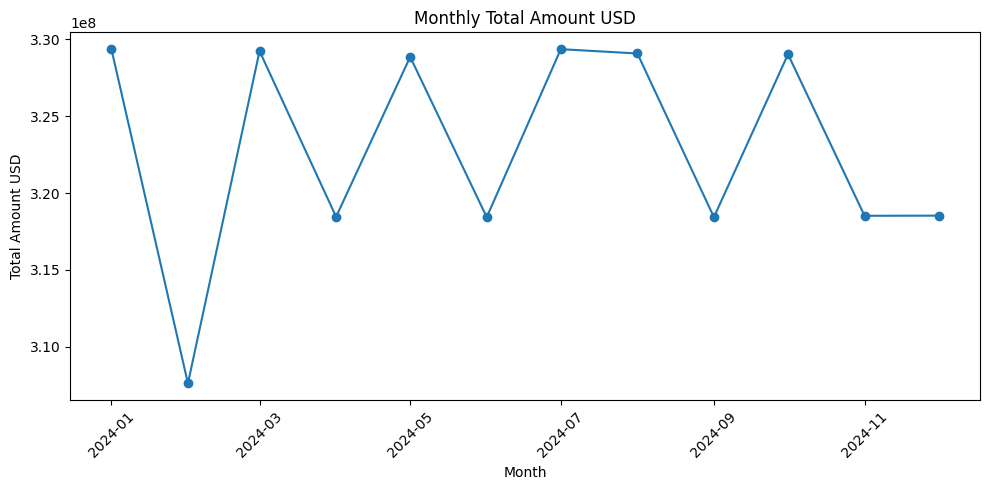

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_pd["Month"], monthly_pd["total_amount_usd"], marker="o")
plt.title("Monthly Total Amount USD")
plt.xlabel("Month")
plt.ylabel("Total Amount USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 11.2 Category KPIs

In [26]:
category_kpis = (
    interactions_typed_lf
    .group_by("Category")
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Service_ID").n_unique().alias("active_services"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        pl.col("Amount_USD").mean().alias("avg_amount_usd"),
        pl.col("Amount_USD").median().alias("median_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
    )
    .with_columns(
        (pl.col("total_amount_usd") / pl.col("active_users")).alias("amount_per_active_user"),
        (pl.col("n_transactions") / pl.col("active_users")).alias("transactions_per_active_user"),
    )
    .sort("total_amount_usd", descending=True)
    .collect()
)

display(category_kpis.to_pandas())
category_kpis.write_parquet(WORK_DIR / "category_kpis.parquet")

,Category,n_transactions,active_users,active_services,total_amount_usd,avg_amount_usd,median_amount_usd,completion_rate,amount_per_active_user,transactions_per_active_user
0,Food Delivery,20003439,1999892,50000,1.550510e+09,77.512168,77.52,0.899976,775.296828,10.002260
1,Ride Hailing,10001744,1986565,50000,7.750735e+08,77.493836,77.50,0.900021,390.157638,5.034693
2,E-Commerce,9997890,1986665,50000,7.746178e+08,77.478125,77.47,0.900000,389.908603,5.032499
3,Grocery,4998923,1836666,50000,3.874751e+08,77.511723,77.54,0.900299,210.966575,2.721738
4,Digital Wallet,4998004,1835664,50000,3.872741e+08,77.485762,77.47,0.899899,210.972241,2.722723


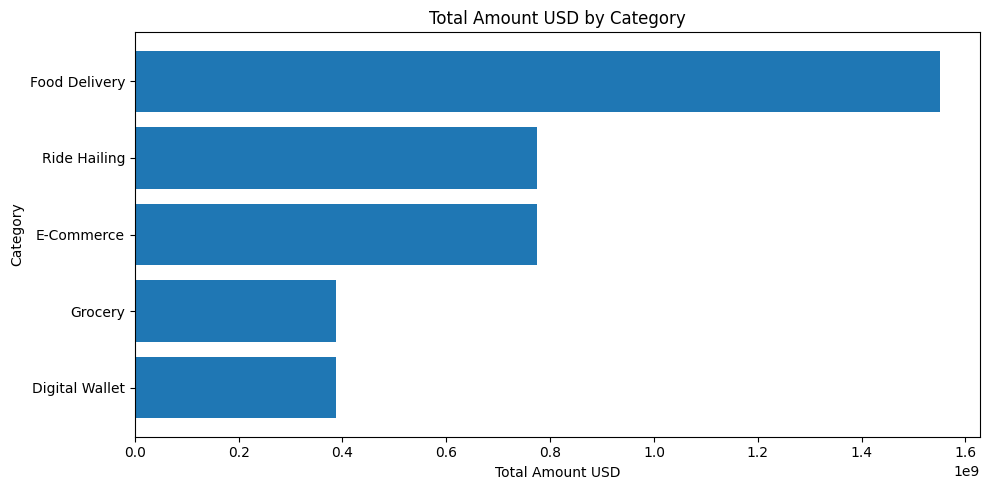

In [27]:
cat_pd = category_kpis.to_pandas().sort_values("total_amount_usd")

plt.figure(figsize=(10, 5))
plt.barh(cat_pd["Category"], cat_pd["total_amount_usd"])
plt.title("Total Amount USD by Category")
plt.xlabel("Total Amount USD")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### 11.3 Monthly category KPIs

In [28]:
monthly_category_kpis = (
    interactions_typed_lf
    .group_by(["Month", "Category"])
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
    )
    .sort(["Month", "Category"])
    .collect()
)

display(monthly_category_kpis.head(20).to_pandas())
monthly_category_kpis.write_parquet(WORK_DIR / "monthly_category_kpis.parquet")

,Month,Category,n_transactions,active_users,total_amount_usd,completion_rate
0,2024-01-01,Digital Wallet,424455,382568,3.288150e+07,0.900055
1,2024-01-01,E-Commerce,850476,692967,6.587101e+07,0.899910
2,2024-01-01,Food Delivery,1699696,1145540,1.317005e+08,0.900028
3,2024-01-01,Grocery,425507,383600,3.298340e+07,0.899757
4,2024-01-01,Ride Hailing,849970,692105,6.593376e+07,0.899948
5,2024-02-01,Digital Wallet,398060,360719,3.083203e+07,0.900407
6,2024-02-01,E-Commerce,793992,655404,6.155137e+07,0.899968
7,2024-02-01,Food Delivery,1586848,1095917,1.229919e+08,0.899927
8,2024-02-01,Grocery,396918,360072,3.082217e+07,0.900249
9,2024-02-01,Ride Hailing,793699,655184,6.142680e+07,0.900427


### 11.4 Status / reliability KPIs

In [29]:
status_kpis = (
    interactions_typed_lf
    .group_by(["Category", "Status"])
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        pl.col("User_ID").n_unique().alias("active_users"),
    )
    .with_columns(
        (pl.col("n_transactions") / pl.col("n_transactions").sum().over("Category")).alias("status_share_within_category")
    )
    .sort(["Category", "n_transactions"], descending=[False, True])
    .collect()
)

display(status_kpis.to_pandas())
status_kpis.write_parquet(WORK_DIR / "status_kpis.parquet")

,Category,Status,n_transactions,total_amount_usd,active_users,status_share_within_category
0,Digital Wallet,Completed,4497700,3.484842e+08,1789067,0.899899
1,Digital Wallet,Failed,250316,1.942324e+07,235314,0.050083
2,Digital Wallet,Refunded,249988,1.936673e+07,234690,0.050018
3,E-Commerce,Completed,8998097,6.971648e+08,1977990,0.900000
4,E-Commerce,Refunded,500027,3.872758e+07,442105,0.050013
5,E-Commerce,Failed,499766,3.872538e+07,442478,0.049987
6,Food Delivery,Completed,18002608,1.395385e+09,1999741,0.899976
7,Food Delivery,Refunded,1000679,7.757122e+07,787807,0.050025
8,Food Delivery,Failed,1000152,7.755335e+07,786674,0.049999
9,Grocery,Completed,4500524,3.488318e+08,1790104,0.900299


### 11.5 Referral source KPIs

In [30]:
referral_kpis = (
    interactions_typed_lf
    .group_by("Referral_Source")
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        pl.col("Amount_USD").mean().alias("avg_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
    )
    .with_columns(
        (pl.col("total_amount_usd") / pl.col("active_users")).alias("amount_per_active_user"),
        (pl.col("n_transactions") / pl.col("active_users")).alias("transactions_per_active_user"),
    )
    .sort("total_amount_usd", descending=True)
    .collect()
)

display(referral_kpis.to_pandas())
referral_kpis.write_parquet(WORK_DIR / "referral_kpis.parquet")

,Referral_Source,n_transactions,active_users,total_amount_usd,avg_amount_usd,completion_rate,amount_per_active_user,transactions_per_active_user
0,Organic Search,10001835,1986626,7.752136e+08,77.507140,0.899929,390.216190,5.034584
1,Email Promo,10002456,1986377,7.750712e+08,77.488092,0.899991,390.193417,5.035527
2,Push Notification,10003037,1986579,7.750340e+08,77.479865,0.900077,390.134981,5.035308
3,Friend Referral,9998636,1986463,7.749682e+08,77.507391,0.900041,390.124654,5.033386
4,Social Ad,9994036,1986583,7.746635e+08,77.512577,0.900033,389.947704,5.030767


### 11.6 Device / platform KPIs

In [31]:
platform_kpis = (
    interactions_typed_lf
    .group_by("Platform_User_Agent")
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
    )
    .with_columns(
        (pl.col("n_transactions") / pl.col("active_users")).alias("transactions_per_active_user")
    )
    .sort("n_transactions", descending=True)
    .collect()
)

display(platform_kpis.to_pandas())
platform_kpis.write_parquet(WORK_DIR / "platform_kpis.parquet")

,Platform_User_Agent,n_transactions,active_users,total_amount_usd,completion_rate,transactions_per_active_user
0,Nova Lite (Android Go),12505490,1996175,9.692141e+08,0.900051,6.264726
1,Nova App v4.2 (iOS 17.1; iPhone 14 Pro),12501716,1996141,9.688391e+08,0.899980,6.262942
2,Nova App v4.2 (Android 14; Samsung S23),12497978,1996135,9.686251e+08,0.899858,6.261089
3,Nova Web Portal (Chrome 120.0),12494816,1996180,9.682723e+08,0.900169,6.259363


### 11.7 Hourly behavior KPIs

In [32]:
hourly_kpis = (
    interactions_typed_lf
    .group_by("Hour")
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        pl.col("Amount_USD").mean().alias("avg_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
    )
    .sort("Hour")
    .collect()
)

display(hourly_kpis.to_pandas())
hourly_kpis.write_parquet(WORK_DIR / "hourly_kpis.parquet")

,Hour,n_transactions,active_users,total_amount_usd,avg_amount_usd,completion_rate
0,0,2083518,1294617,1.614600e+08,77.493933,0.900145
1,1,2085107,1294493,1.614848e+08,77.446779,0.899857
2,2,2084502,1294500,1.614689e+08,77.461635,0.900191
3,3,2080984,1292936,1.611797e+08,77.453603,0.899833
4,4,2082805,1294207,1.614448e+08,77.513176,0.900168
5,5,2083304,1294193,1.614203e+08,77.482844,0.900137
6,6,2083306,1294274,1.613307e+08,77.439737,0.899828
7,7,2083672,1294290,1.616256e+08,77.567702,0.900137
8,8,2082560,1294802,1.612897e+08,77.447787,0.899995
9,9,2086581,1295143,1.617917e+08,77.539136,0.900421


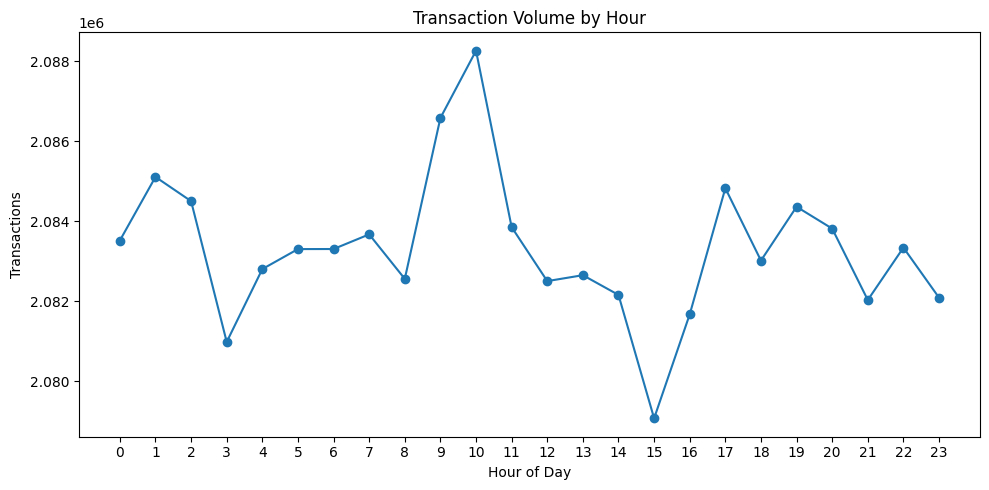

In [33]:
hourly_pd = hourly_kpis.to_pandas()

plt.figure(figsize=(10, 5))
plt.plot(hourly_pd["Hour"], hourly_pd["n_transactions"], marker="o")
plt.title("Transaction Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transactions")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 11.8 Service / merchant performance KPIs

This joins the service dimension to summarize merchant performance.


In [34]:
service_kpis = (
    interactions_typed_lf
    .group_by("Service_ID")
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        pl.col("Amount_USD").mean().alias("avg_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
    )
    .join(services.lazy(), on="Service_ID", how="left")
    .with_columns(
        (pl.col("n_transactions") / pl.col("active_users")).alias("transactions_per_active_user")
    )
    .sort("total_amount_usd", descending=True)
    .collect()
)

display(service_kpis.head(30).to_pandas())
service_kpis.write_parquet(WORK_DIR / "service_kpis.parquet")

,Service_ID,n_transactions,active_users,total_amount_usd,avg_amount_usd,completion_rate,Merchant_Name,Category,Rating,transactions_per_active_user
0,11195,1098,1097,89544.84,81.552678,0.896175,Store_11195,Food Delivery,4.8,1.000912
1,40352,1116,1116,89329.83,80.044651,0.894265,Store_40352,E-Commerce,3.7,1.000000
2,39004,1117,1116,89313.60,79.958460,0.896150,Store_39004,Food Delivery,3.6,1.000896
3,38735,1113,1113,89001.77,79.965651,0.915544,Store_38735,Digital Wallet,4.3,1.000000
4,25181,1061,1061,88495.43,83.407568,0.900094,Store_25181,Ride Hailing,3.7,1.000000
5,23239,1101,1100,88105.99,80.023606,0.911898,Store_23239,Ride Hailing,4.5,1.000909
6,72,1109,1109,87831.32,79.198665,0.902615,Store_72,Digital Wallet,4.5,1.000000
7,47381,1119,1119,87775.11,78.440670,0.913315,Store_47381,E-Commerce,3.1,1.000000
8,17867,1125,1125,87689.04,77.945813,0.904000,Store_17867,Digital Wallet,4.5,1.000000
9,44362,1111,1111,87682.51,78.922151,0.902790,Store_44362,Grocery,4.2,1.000000


## 12. User lifecycle and retention-oriented feature tables

These tables are useful for both BI and ML. They aggregate 50M interactions down to one row per user.


In [35]:
user_activity = (
    interactions_typed_lf
    .group_by("User_ID")
    .agg(
        pl.col("Timestamp_dt").min().alias("first_transaction_ts"),
        pl.col("Timestamp_dt").max().alias("last_transaction_ts"),
        pl.len().alias("n_transactions"),
        pl.col("Service_ID").n_unique().alias("n_services_used"),
        pl.col("Category").n_unique().alias("n_categories_used"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
        pl.col("Amount_USD").mean().alias("avg_amount_usd"),
        (pl.col("Status") == "Completed").mean().alias("completion_rate"),
    )
    .with_columns(
        (pl.col("last_transaction_ts") - pl.col("first_transaction_ts")).dt.total_days().alias("activity_span_days"),
        (pl.col("n_transactions") > 1).alias("is_repeat_user"),
        (pl.col("n_services_used") > 1).alias("is_multi_service_user"),
    )
    .join(users.lazy(), on="User_ID", how="left")
    .collect()
)

display(user_activity.head().to_pandas())
user_activity.write_parquet(WORK_DIR / "user_activity_features.parquet")

,User_ID,first_transaction_ts,last_transaction_ts,n_transactions,n_services_used,n_categories_used,total_amount_usd,avg_amount_usd,completion_rate,activity_span_days,is_repeat_user,is_multi_service_user,Join_Date,Membership_Tier,Primary_Device
0,827153,2024-01-14 12:31:59,2024-12-28 10:39:12,27,27,4,1944.69,72.025556,0.888889,348,True,True,2023-02-14,Platinum,Android
1,1482650,2024-01-27 14:56:39,2024-12-02 12:36:02,21,21,5,1663.49,79.213810,0.857143,309,True,True,2023-06-25,Platinum,Android
2,1961106,2024-01-31 20:51:18,2024-11-30 09:29:25,17,17,5,1379.95,81.173529,0.823529,303,True,True,2023-05-04,Standard,iOS
3,1116429,2024-01-04 14:58:29,2024-12-26 08:27:50,38,38,5,2861.12,75.292632,0.815789,356,True,True,2023-01-04,Standard,iOS
4,459306,2024-01-02 05:23:17,2024-12-21 03:10:42,32,32,5,2700.48,84.390000,0.937500,353,True,True,2023-06-09,Standard,Android


In [36]:
user_activity_summary = user_activity.select(
    pl.len().alias("n_users_with_activity"),
    pl.col("n_transactions").mean().alias("avg_transactions_per_user"),
    pl.col("n_transactions").median().alias("median_transactions_per_user"),
    pl.col("n_services_used").mean().alias("avg_services_used"),
    pl.col("is_repeat_user").mean().alias("repeat_user_rate"),
    pl.col("is_multi_service_user").mean().alias("multi_service_user_rate"),
    pl.col("total_amount_usd").mean().alias("avg_total_amount_per_user"),
    pl.col("activity_span_days").mean().alias("avg_activity_span_days"),
)

display(user_activity_summary.to_pandas())

,n_users_with_activity,avg_transactions_per_user,median_transactions_per_user,avg_services_used,repeat_user_rate,multi_service_user_rate,avg_total_amount_per_user,avg_activity_span_days
0,2000000,25.0,25.0,24.99371,1.0,1.0,1937.475245,335.315264


### 12.1 Cohort-style table by user join month

This uses `Join_Date` from the user dimension and transaction activity from the fact table.


In [37]:
user_activity_cohorts = (
    user_activity
    .with_columns(
        pl.col("Join_Date").dt.truncate("1mo").alias("Join_Month"),
        pl.col("first_transaction_ts").dt.truncate("1mo").alias("First_Transaction_Month"),
    )
    .group_by("Join_Month")
    .agg(
        pl.len().alias("n_active_users_from_join_cohort"),
        pl.col("n_transactions").mean().alias("avg_transactions"),
        pl.col("n_services_used").mean().alias("avg_services_used"),
        pl.col("is_repeat_user").mean().alias("repeat_user_rate"),
        pl.col("is_multi_service_user").mean().alias("multi_service_user_rate"),
        pl.col("total_amount_usd").mean().alias("avg_total_amount_usd"),
    )
    .sort("Join_Month")
)

display(user_activity_cohorts.to_pandas())
user_activity_cohorts.write_parquet(WORK_DIR / "user_activity_cohorts.parquet")

,Join_Month,n_active_users_from_join_cohort,avg_transactions,avg_services_used,repeat_user_rate,multi_service_user_rate,avg_total_amount_usd
0,2023-01-01,170151,24.991419,24.985043,1.0,1.0,1936.989650
1,2023-02-01,153544,25.000143,24.993728,1.0,1.0,1937.066398
2,2023-03-01,170191,24.988771,24.982843,1.0,1.0,1937.290618
3,2023-04-01,165012,25.004818,24.998618,1.0,1.0,1938.132651
4,2023-05-01,169225,25.015482,25.009449,1.0,1.0,1937.764488
5,2023-06-01,163567,24.994424,24.987858,1.0,1.0,1936.811101
6,2023-07-01,170134,24.998119,24.991883,1.0,1.0,1937.476960
7,2023-08-01,169522,25.002855,24.996514,1.0,1.0,1937.901514
8,2023-09-01,164070,24.986597,24.980332,1.0,1.0,1936.912245
9,2023-10-01,169775,24.999287,24.992867,1.0,1.0,1936.875868


## 13. Cross-sell / super-app adoption analysis

The main question: do users remain single-service users, or do they adopt multiple services?


In [38]:
service_count_distribution = (
    user_activity
    .group_by("n_services_used")
    .agg(pl.len().alias("n_users"))
    .with_columns((pl.col("n_users") / pl.col("n_users").sum()).alias("user_share"))
    .sort("n_services_used")
)

display(service_count_distribution.to_pandas())
service_count_distribution.write_parquet(WORK_DIR / "service_count_distribution.parquet")

,n_services_used,n_users,user_share
0,4,1,5.000000e-07
1,5,2,1.000000e-06
2,6,11,5.500000e-06
3,7,30,1.500000e-05
4,8,123,6.150000e-05
5,9,300,1.500000e-04
6,10,695,3.475000e-04
7,11,1713,8.565000e-04
8,12,3393,1.696500e-03
9,13,6545,3.272500e-03


In [39]:
category_count_distribution = (
    user_activity
    .group_by("n_categories_used")
    .agg(pl.len().alias("n_users"))
    .with_columns((pl.col("n_users") / pl.col("n_users").sum()).alias("user_share"))
    .sort("n_categories_used")
)

display(category_count_distribution.to_pandas())
category_count_distribution.write_parquet(WORK_DIR / "category_count_distribution.parquet")

,n_categories_used,n_users,user_share
0,1,1,5.000000e-07
1,2,195,9.750000e-05
2,3,17447,8.723500e-03
3,4,319065,1.595325e-01
4,5,1663292,8.316460e-01


## 14. Candidate ML feature table

This creates a compact user-level table that could support models such as:

- Predict repeat user
- Predict multi-service adoption
- Predict high-value user
- Predict low completion / reliability risk

This is not final modeling code. It is a feature exploration base.


In [40]:
ml_user_features = (
    user_activity
    .with_columns(
        (pl.col("total_amount_usd") >= pl.col("total_amount_usd").quantile(0.80)).alias("is_top_20pct_value_user"),
    )
    .select(
        "User_ID",
        "Membership_Tier",
        "Primary_Device",
        "Join_Date",
        "n_transactions",
        "n_services_used",
        "n_categories_used",
        "total_amount_usd",
        "avg_amount_usd",
        "completion_rate",
        "activity_span_days",
        "is_repeat_user",
        "is_multi_service_user",
        "is_top_20pct_value_user",
    )
)

display(ml_user_features.head().to_pandas())
ml_user_features.write_parquet(WORK_DIR / "ml_user_features.parquet")

,User_ID,Membership_Tier,Primary_Device,Join_Date,n_transactions,n_services_used,n_categories_used,total_amount_usd,avg_amount_usd,completion_rate,activity_span_days,is_repeat_user,is_multi_service_user,is_top_20pct_value_user
0,827153,Platinum,Android,2023-02-14,27,27,4,1944.69,72.025556,0.888889,348,True,True,False
1,1482650,Platinum,Android,2023-06-25,21,21,5,1663.49,79.213810,0.857143,309,True,True,False
2,1961106,Standard,iOS,2023-05-04,17,17,5,1379.95,81.173529,0.823529,303,True,True,False
3,1116429,Standard,iOS,2023-01-04,38,38,5,2861.12,75.292632,0.815789,356,True,True,True
4,459306,Standard,Android,2023-06-09,32,32,5,2700.48,84.390000,0.937500,353,True,True,True


## 15. Suggested business problem shortlist

Based on the available columns, the strongest project directions are:

### A. Executive super-app performance dashboard

**Question:** How is Nova performing across time, service categories, referral sources, platforms, and transaction statuses?

Core KPIs:

- Total transaction volume
- Active users
- Total amount / GMV proxy
- Average transaction amount
- Transactions per active user
- Completion rate
- Category contribution to total amount

Useful tables from this notebook:

- `monthly_kpis.parquet`
- `category_kpis.parquet`
- `monthly_category_kpis.parquet`
- `referral_kpis.parquet`
- `platform_kpis.parquet`

### B. User lifecycle and retention analysis

**Question:** Which users become repeat, high-value, and multi-service users?

Core KPIs:

- Repeat user rate
- Multi-service user rate
- Average services used per user
- Transactions per user
- Activity span
- Total amount per user
- Join cohort behavior

Useful tables:

- `user_activity_features.parquet`
- `user_activity_cohorts.parquet`
- `ml_user_features.parquet`

### C. Cross-sell / super-app adoption

**Question:** Which categories and user segments are associated with broader super-app adoption?

Core KPIs:

- Distinct services per user
- Distinct categories per user
- Multi-service adoption rate
- Category mix by user segment

Useful tables:

- `service_count_distribution.parquet`
- `category_count_distribution.parquet`
- `user_activity_features.parquet`

### D. Payment / transaction reliability

**Question:** Where do incomplete or failed transactions concentrate?

Core KPIs:

- Completion rate by category
- Completion rate by platform
- Completion rate by referral source
- Status distribution by category
- Low-rated/high-failure merchants

Useful tables:

- `status_kpis.parquet`
- `category_kpis.parquet`
- `service_kpis.parquet`
- `platform_kpis.parquet`

### E. Merchant / service performance

**Question:** Which merchants/services are high-volume, high-value, or operationally weak?

Core KPIs:

- Transactions by service
- Total amount by service
- Active users by service
- Completion rate by service
- Average rating by service/category

Useful tables:

- `service_kpis.parquet`
- `category_kpis.parquet`


## 16. Suggested dbt model structure for the later project

A reasonable BigQuery + dbt structure:

```text
models/
  staging/
    stg_nova__interactions.sql
    stg_nova__users.sql
    stg_nova__services.sql
  intermediate/
    int_nova__user_activity.sql
    int_nova__service_performance.sql
    int_nova__monthly_category_kpis.sql
  marts/
    fct_transactions.sql
    dim_users.sql
    dim_services.sql
    mart_executive_monthly_kpis.sql
    mart_category_performance.sql
    mart_user_lifecycle.sql
    mart_service_reliability.sql
```

Candidate dbt tests:

```text
not_null: Transaction_UUID, User_ID, Service_ID, Timestamp
unique: Transaction_UUID
relationships: interactions.User_ID -> users.User_ID
relationships: interactions.Service_ID -> services.Service_ID
accepted_values: Status, Category, Membership_Tier, Primary_Device
expression tests: Amount_USD > 0, GPS_Lat between -90 and 90, GPS_Long between -180 and 180
```


## 17. Export summary artifacts

The notebook writes lightweight Parquet outputs to `data/processed/nova_outputs/`. These can be reused in later notebooks.


In [41]:
print("Generated files:")
for path in sorted(WORK_DIR.glob("*")):
    print(path.name, f"{path.stat().st_size / (1024**2):.2f} MiB")

Generated files:
category_count_distribution.parquet 0.00 MiB
category_kpis.parquet 0.00 MiB
hourly_kpis.parquet 0.00 MiB
interactions_sample_0_1pct.parquet 2.68 MiB
ml_user_features.parquet 32.32 MiB
monthly_category_kpis.parquet 0.00 MiB
monthly_kpis.parquet 0.00 MiB
platform_kpis.parquet 0.00 MiB
referral_kpis.parquet 0.00 MiB
service_count_distribution.parquet 0.00 MiB
service_kpis.parquet 1.07 MiB
services.parquet 0.18 MiB
status_kpis.parquet 0.00 MiB
user_activity_cohorts.parquet 0.00 MiB
user_activity_features.parquet 53.42 MiB
users.parquet 4.66 MiB


## 18. Next steps

After running this notebook:

1. Review actual values in `Status`, `Category`, `Platform_User_Agent`, and `Referral_Source`.
2. Decide the primary dashboard angle: executive performance, lifecycle/retention, cross-sell, reliability, or merchant performance.
3. Use the KPI tables as prototypes for dbt marts.
4. Load raw CSVs or converted Parquet files into BigQuery.
5. Build staging models in dbt with data tests.
6. Build marts matching the dashboard pages.
7. Use `ml_user_features.parquet` or a BigQuery equivalent for first modeling experiments.
